In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

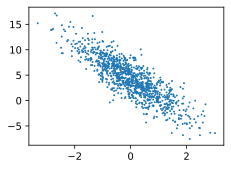

In [2]:
def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1)

In [3]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(num_examples, batch_size + i)])

        yield features[batch_indices], labels[batch_indices]

In [4]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def linreg(X, w, b): #@save
    return torch.matmul(X, w) + b

def squared_loss(y_hat, y): 
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()





In [5]:
lr = 0.03
num_epochs = 5
net = linreg
loss = squared_loss
batch_size = 10

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()

        sgd([w, b], lr, batch_size)
    
    with torch.no_grad():
        train_l = loss(net(X, w, b), y)
        print(f'epoch: {epoch + 1}, loss: {float(train_l.mean()):f}')

epoch: 1, loss: 0.033614
epoch: 2, loss: 0.000082
epoch: 3, loss: 0.000017
epoch: 4, loss: 0.000061
epoch: 5, loss: 0.000051
